In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# !pip install scikit-optimize

In [4]:
# from skopt import gp_minimize
# from skopt import space

In [5]:
import guides
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [6]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 20) * k_0

# normalized simulation lengths
substrate_length = (6 * lambd) * k_0
core_length = (2 * lambd) * k_0
cladding_length = (6 * lambd) * k_0

# refractive indices
n_substrate = 1.5
n_core = 1.7
n_cladding = 1.2

In [7]:
study = 'TM'
field_type = 'E'

In [8]:
RIs = [n_substrate, n_core, n_cladding]
lengths = [substrate_length, core_length, cladding_length]

In [9]:
reference_device = guides.SlabWaveguide(RIs, lambd, lengths, study=study, field_type=field_type)

In [18]:
memory_type = torch.device('cpu')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 3

In [19]:
base_model = models.discontinuity_capturing_network(1, 128, num_modes, 2, 'Siren')
optimzer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[2000, 3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 17283


In [20]:
device = guides.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)

In [21]:
train_agent = trainers.Trainer(dtype, device, memory_type, [samplers.uniform_grid], optimzer, scheduler, dx)

In [22]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1/16, 1/4, 10, 1, 1, 1], verbose=1, sample_new=False)

num PDE samples 279
num rayleigh samples 279
iteration 1 loss1 is 0.41353, loss2 is 0.03017, loss3 is 0.36304, loss4 is 1.13727, loss5 is 0.52939, loss6 is 0.54088
iteration 1001 loss1 is 0.00173, loss2 is 0.0009, loss3 is 0.00062, loss4 is 0.0, loss5 is 1e-05, loss6 is 5e-05
iteration 2001 loss1 is 0.00082, loss2 is 0.00061, loss3 is 0.00028, loss4 is 0.0, loss5 is 0.0, loss6 is 1e-05
iteration 3001 loss1 is 0.0004, loss2 is 0.00056, loss3 is 0.00013, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0
iteration 4001 loss1 is 0.00035, loss2 is 0.00054, loss3 is 0.00011, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0
iteration 5001 loss1 is 0.00032, loss2 is 0.00052, loss3 is 0.00011, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0
iteration 6001 loss1 is 0.00028, loss2 is 0.00049, loss3 is 9e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0
iteration 7001 loss1 is 0.00022, loss2 is 0.00043, loss3 is 7e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0
iteration 8001 loss1 is 0.00017, loss2 is 0.00037, loss3 is 6e-05,

# FD Performance

adjusting analytic solution for Ex in a TM study
**********
mode errors
**********
relative error for mode 0 is 2.29763%
**********
**********
relative error for mode 1 is 3.58853%
**********
**********
relative error for mode 2 is 4.37458%
**********


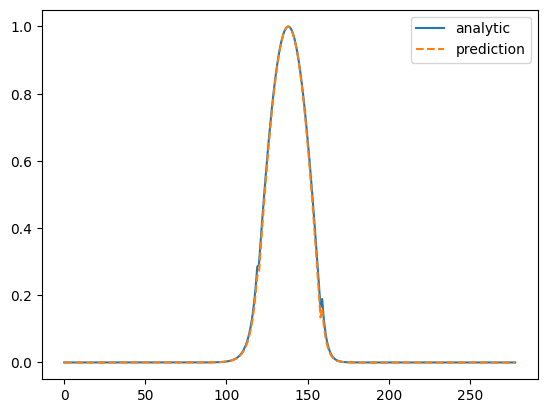

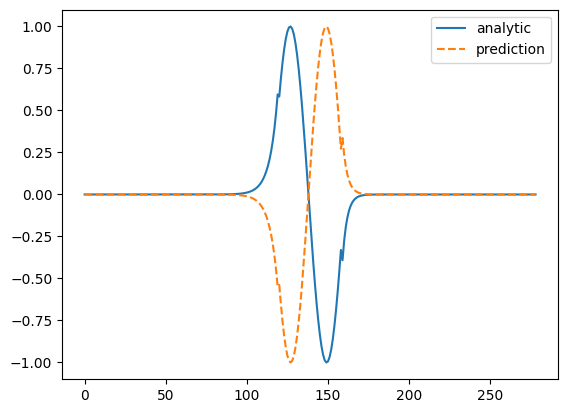

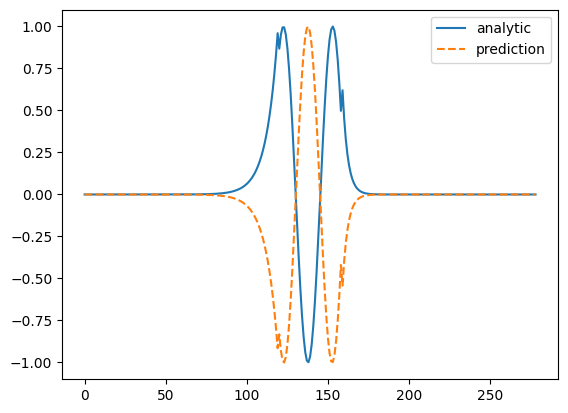

In [23]:
fd_device = guides.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u));

In [24]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments"

In [25]:
# fd_device = guides.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
# 
# evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = fd_device.evaluate_analytical(x, num_modes)
# 
# if fd_device.study == 'TM' and fd_device.field_type=='E':
#   print('adjusting analytic solution for Ex in a TM study')
#   eigen_funcs_analytic = eigen_funcs_analytic / fd_device.refractive_index(evaluation_points.reshape(-1), format='numpy')**2
# 
# eigen_funcs_analytic /= np.max(np.abs(eigen_funcs_analytic), axis=-1, keepdims=True)
# 
# print(eigen_funcs_analytic.shape, eigen_modes_analytic.shape)
# 
# np.save(save_folder_path + r"\Planar\Several Modes Moderate Contrast\analytic_EIs.npy", eigen_modes_analytic)
# np.save(save_folder_path + r"\Planar\Several Modes Moderate Contrast\analytic_fields.npy", eigen_funcs_analytic)

In [26]:
# _, x, u = fd_device.evaluate(num_modes)
# print(_.shape, u.T.shape)
# u = u/np.max(np.abs(u), axis=0, keepdims=True)
# np.save(save_folder_path + r"\Planar\Several Modes Moderate Contrast\FD_EIs.npy", _)
# np.save(save_folder_path + r"\Planar\Several Modes Moderate Contrast\FD_fields.npy", u.T)

In [27]:
# plt.plot(eigen_funcs_analytic[2])
# plt.plot(u.T[2], linestyle='--')

In [28]:
mode_errors = []
num_modes = len(u.T)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)

if reference_device.study == 'TM':
  evaluation_pts_error = (torch.mean((torch.from_numpy(evaluation_points).reshape(-1) - x.reshape(-1)) ** 2) / np.mean(
          evaluation_points.reshape(-1) ** 2)) ** 0.5 * 100
  print(f'evalution points are at an error of {round(evaluation_pts_error.item(), 5)}%')

  if reference_device.field_type=='E':
    eigen_funcs_analytic = eigen_funcs_analytic / device.refractive_index(evaluation_points, format='numpy')**2
    eigen_funcs_analytic /= np.linalg.norm(eigen_funcs_analytic, axis=-1, keepdims=True)

evalution points are at an error of 0.0%


# NN Performance

adjusting analytic solution for Ex in a TM study
**********
mode errors
**********
relative error for mode 0 is 1.14993%
**********
**********
relative error for mode 1 is 0.93271%
**********
**********
relative error for mode 2 is 1.30504%
**********


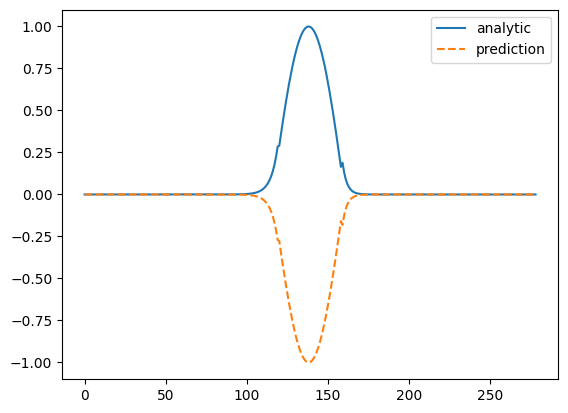

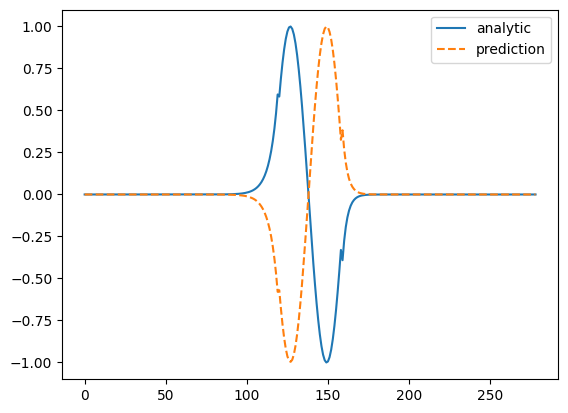

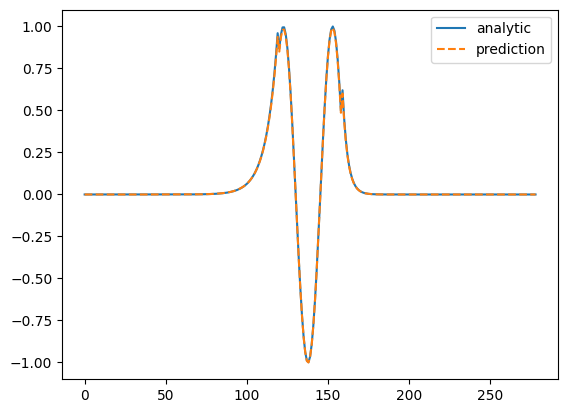

In [29]:
augmented_x = torch.cat((torch.from_numpy(evaluation_points).reshape(-1, 1), device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)
predictions = device.underlying_model(augmented_x)
prediction_normed = predictions.detach().cpu() / torch.max(torch.abs(predictions.detach().cpu()), dim=0, keepdims=True)[0]

utils.compare_against_analytic(reference_device, x, prediction_normed.detach().cpu());

In [30]:
x_tensor = torch.from_numpy(x)
x_tensor.requires_grad = True
x_augmented = torch.cat((x_tensor.reshape(-1, 1), device.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1)
NN_EI = [device.calculate_eigen_value(x_augmented.to(memory_type), 0).item()**(1/2), device.calculate_eigen_value(x_augmented.to(memory_type), 1).item()**(1/2), device.calculate_eigen_value(x_augmented.to(memory_type), 2).item()**(1/2)]

_**(1/2), '\n', reference_device.evaluate_analytical(x, 3)[1], '\n', NN_EI

(array([1.68443586, 1.63793122, 1.56251381]),
 '\n',
 array([1.68508884, 1.64043889, 1.56756803]),
 '\n',
 [1.6849824626419019, 1.6400948777894444, 1.5668174161014403])

In [34]:
# np.save(save_folder_path + r"\Planar\Several Modes Moderate Contrast\DCNN_EIs.npy", NN_EI)
# np.save(save_folder_path + r"\Planar\Several Modes Moderate Contrast\DCNN_fields.npy", prediction_normed.T.numpy())

In [35]:
# test = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\DCNN_EIs.npy")
# print(test.shape)
# test = np.load(save_folder_path + r"\Planar\Several Modes Moderate Contrast\DCNN_fields.npy")
# print(test.shape)
# plt.plot(test[1]);
# plt.plot()